In [139]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns


In [140]:
df = pd.read_csv(r'indian_engineering_student_placement.csv')
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [141]:
df1 = pd.read_csv(r"placement_targets.csv")
df1.head()

,Student_ID,placement_status,salary_lpa
0,1,Placed,14.95
1,2,Placed,14.91
2,3,Placed,17.73
3,4,Placed,14.52
4,5,Placed,15.91


In [142]:
columns_drop = ['Student_ID','gender','study_hours_per_day','sleep_hours','stress_level','part_time_job','family_income_level','internet_access']
df = df.drop(columns = columns_drop,axis=1)

In [143]:
for i in df1['placement_status']:
    if i == 'Placed':
        df1['status'] = 1
    else:
        df1['status'] = 0
        

In [144]:
numerical_feature =  ['cgpa','tenth_percentage','twelfth_percentage','backlogs',
                      'attendance_percentage','projects_completed','internships_completed',
                      'coding_skill_rating','communication_skill_rating','aptitude_skill_rating',
                      'hackathons_participated','certifications_count']
categorical_feature = ['branch','city_tier','extracurricular_involvement']

In [145]:
preprocessor = ColumnTransformer(
    transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'),categorical_feature),
    ('num', 'passthrough',numerical_feature)
    ]
    
)

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   branch                       5000 non-null   object 
 1   cgpa                         5000 non-null   float64
 2   tenth_percentage             5000 non-null   float64
 3   twelfth_percentage           5000 non-null   float64
 4   backlogs                     5000 non-null   int64  
 5   attendance_percentage        5000 non-null   float64
 6   projects_completed           5000 non-null   int64  
 7   internships_completed        5000 non-null   int64  
 8   coding_skill_rating          5000 non-null   int64  
 9   communication_skill_rating   5000 non-null   int64  
 10  aptitude_skill_rating        5000 non-null   int64  
 11  hackathons_participated      5000 non-null   int64  
 12  certifications_count         5000 non-null   int64  
 13  city_tier         

In [147]:
df1 = df1.drop(columns = 'Student_ID', axis=1)

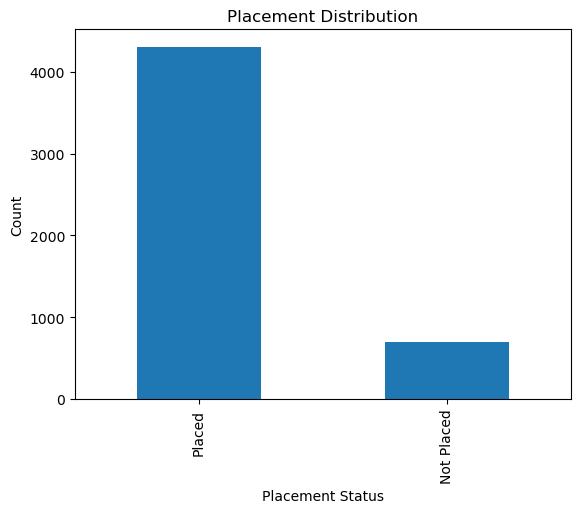

In [148]:
plt.figure()
df1['placement_status'].value_counts().plot(kind='bar')
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.title("Placement Distribution")
plt.show()

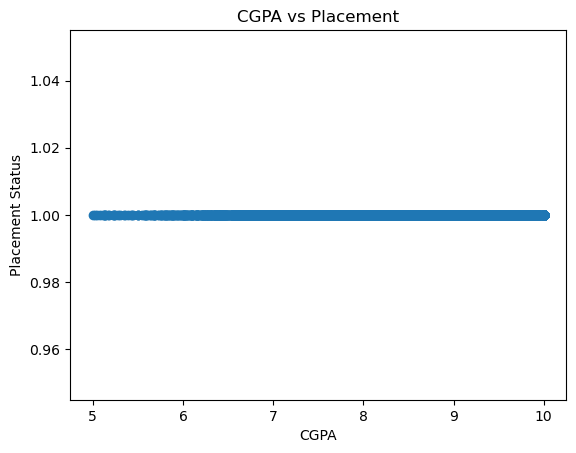

In [149]:
plt.figure()
plt.scatter(df['cgpa'], df1['status'])
plt.xlabel("CGPA")
plt.ylabel("Placement Status")
plt.title("CGPA vs Placement")
plt.show()

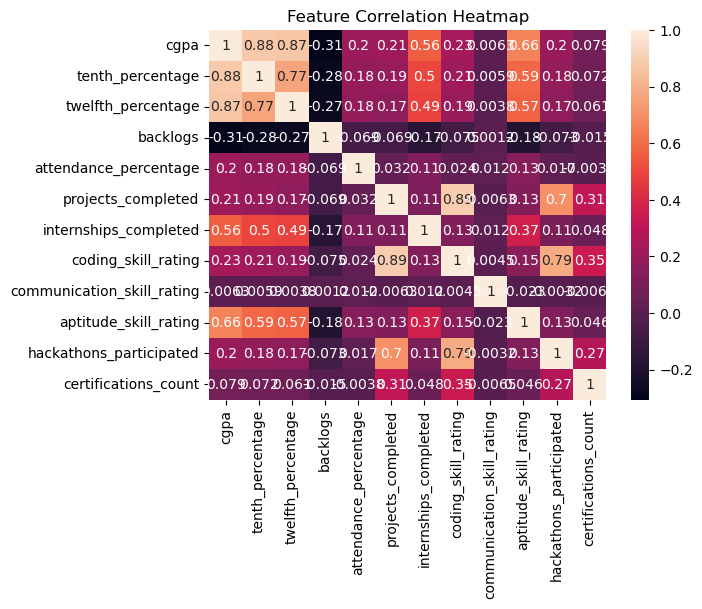

In [150]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

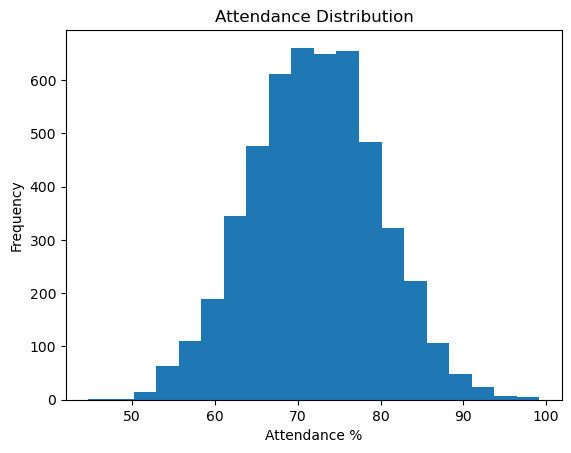

In [151]:
plt.figure()
plt.hist(df['attendance_percentage'], bins=20)
plt.xlabel("Attendance %")
plt.ylabel("Frequency")
plt.title("Attendance Distribution")
plt.show()

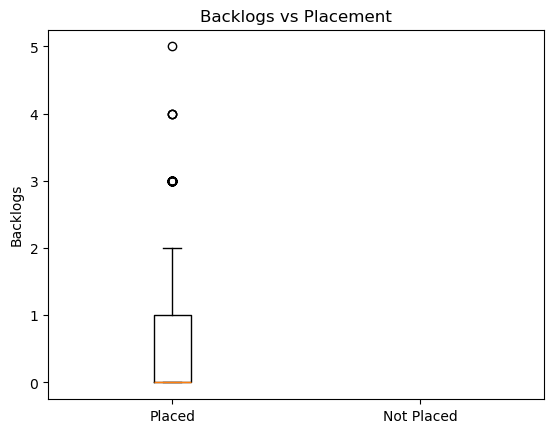

In [152]:
plt.figure()
plt.boxplot([df[df1['status']==1]['backlogs'], df[df1['status']==0]['backlogs']])
plt.xticks([1,2], ['Placed','Not Placed'])
plt.ylabel("Backlogs")
plt.title("Backlogs vs Placement")
plt.show()

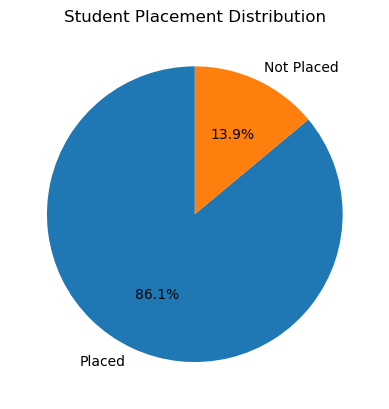

In [153]:
placement_counts = df1['placement_status'].value_counts()

plt.figure()
plt.pie(
    placement_counts,
    labels=placement_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Student Placement Distribution")
plt.show()

In [154]:
x = (df[['branch','cgpa','tenth_percentage','twelfth_percentage',
                 'backlogs','attendance_percentage','projects_completed','internships_completed',
                 'coding_skill_rating','communication_skill_rating','aptitude_skill_rating',
                 'hackathons_participated','certifications_count','city_tier','extracurricular_involvement']])

In [155]:
y = (df1[['status']])

In [156]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.25 )

In [157]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators = 450, random_state=42))
])

In [158]:
model.fit(x_train, y_train)

C:\Users\patel\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['branch', 'city_tier',
                                                   'extracurricular_involvement']),
                                                 ('num', 'passthrough',
                                                  ['cgpa', 'tenth_percentage',
                                                   'twelfth_percentage',
                                                   'backlogs',
                                                   'attendance_percentage',
                                                   'projects_completed',
                                                   'internships_completed',
                                                   'coding_skill_rating',
                                                   'communication_skill_rating',
                                                   'aptitude_skill_rating',
                                                   'hackathons_participated',
                                                   'certifications_count'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=450, random_state=42))])

In [160]:
y_pred = model.predict(x_test)

In [161]:
recall_score(y_test,y_pred)

0.8672

In [162]:
recall = recall_score(y_test,y_pred)
print("Recall score of our model is:",recall)

Recall score of our model is: 0.8672


In [163]:
cm = confusion_matrix(y_test,y_pred,labels=[0,1])
print(cm)

[[   0    0]
 [ 166 1084]]


In [164]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy score of our project is:", acc)

Accuracy score of our project is: 0.8672


In [165]:
pre = precision_score(y_test, y_pred)
print("Precision score of our project is:",pre)

Precision score of our project is: 1.0
